In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from geopy.geocoders import Nominatim
import time
from datetime import datetime as dt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
def df_concat(*file_name):
    # concatenates multiple files in a single df
    df_f = pd.DataFrame()
    for i in file_name:
        df_file = pd.read_csv(f'{i}.csv', index_col = 0)
        df_f = pd.concat([df_f, df_file])
    
    # removing duplicated listings
    df_size_with_dups = df_f.shape[0]
    df_f = df_f.drop_duplicates(subset=['url'],keep='last')
    print(f'There are {df_size_with_dups - df_f.shape[0]} duplicates.')
    df_f = df_f.reset_index(drop=True)
    return df_f

In [3]:
df = df_concat('apt_house_sfbay_2023-02-24', 'apt_house_sfbay_2023-03-06')
df_org_size = df.shape[0] # saves the initial number of rows

There are 956 duplicates that


In [5]:
# pd.set_option('display.max_colwidth', None)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12687 entries, 0 to 12686
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   url                    12687 non-null  object 
 1   price                  12687 non-null  object 
 2   area                   12687 non-null  object 
 3   location               12687 non-null  object 
 4   latitude               12687 non-null  float64
 5   longitude              12687 non-null  float64
 6   bedrooms               12687 non-null  int64  
 7   bathrooms              12687 non-null  object 
 8   description            12687 non-null  object 
 9   property_type          12686 non-null  object 
 10  parking                12687 non-null  object 
 11  laundry                12687 non-null  object 
 12  rent_period            12687 non-null  object 
 13  EV_charging            12687 non-null  int64  
 14  air_conditioning       12687 non-null  int64  
 15  fu

In [7]:
df.head()

,url,price,area,location,latitude,longitude,bedrooms,bathrooms,description,property_type,...,rent_period,EV_charging,air_conditioning,furnished,smoking,wheelchair_accessible,cats_allowed,dogs_allowed,room_type,bath_type
0,https://sfbay.craigslist.org/sby/apa/d/sunnyva...,3166,- 811ft,sunnyvale,37.398686,-122.012776,1,1,"['QR Code Link to This Post', 'Call Now -', 's...",apartment,...,monthly,1,1,0,0,1,1,1,NaN,NaN
1,https://sfbay.craigslist.org/sby/apa/d/san-jos...,1874,/ 410ft,san jose east,37.319764,-121.823586,0,1,"['QR Code Link to This Post', 'Lion Villas', '...",apartment,...,monthly,0,1,0,1,0,1,1,NaN,NaN
2,https://sfbay.craigslist.org/sfc/apa/d/san-fra...,2195,/ 550ft,downtown / civic / van ness,37.791700,-122.418600,0,1,"['QR Code Link to This Post', ""601 O'farrell #...",apartment,...,monthly,0,0,0,1,0,1,1,NaN,NaN
3,https://sfbay.craigslist.org/sby/apa/d/mountai...,3095,- 947ft,mountain view,37.389300,-122.078300,2,2,"['QR Code Link to This Post', 'Find the Perfec...",apartment,...,monthly,0,0,0,0,0,1,1,NaN,NaN
4,https://sfbay.craigslist.org/nby/apa/d/sebasto...,1250,/ 400ft,sebastopol,38.394100,-122.843300,0,1,"['QR Code Link to This Post', 'Sebastopol stud...",cottage/cabin,...,monthly,0,0,0,0,0,0,0,NaN,NaN


In [9]:
# The features "room_type" and "bath_type" are used only in listings for rooms in shared properties,
# so we will drop them.
df = df.drop(['room_type', 'bath_type'], axis=1)

#### Cleaning column "price"

In [10]:
df_p = df.copy()

In [11]:
df_p = df_p[df_p['price'].str.isalnum()]
df_p['price'] = df_p['price'].astype(int)

#### Dealing with outliers in column "price"

In [12]:
# Check if we have enough listing for "weekly" and "daily" rent period, or we should drop them
print(f"The number of weekly rent listings is {df_p[df_p['rent_period'] == 'weekly'].shape[0]}")
print(f"The number of daily rent listings is {df_p[df_p['rent_period'] == 'daily'].shape[0]}")

The number of weekly rent listings is 7
The number of daily rent listings is 112


In [13]:
# There is no enugh daily and weekly listing, and their price is significamtly lower than the
# daily and monthly listings, and they are gonna negatively impact the model, so we should drop them
idx_rent_period = df_p[(df_p['rent_period'] == 'weekly') | (df_p['rent_period'] == 'daily')].index
df_p = df_p.drop(idx_rent_period)

# And let's drop the entire column since we have only one value
df_p = df_p.drop('rent_period', axis=1)

<AxesSubplot:ylabel='price'>

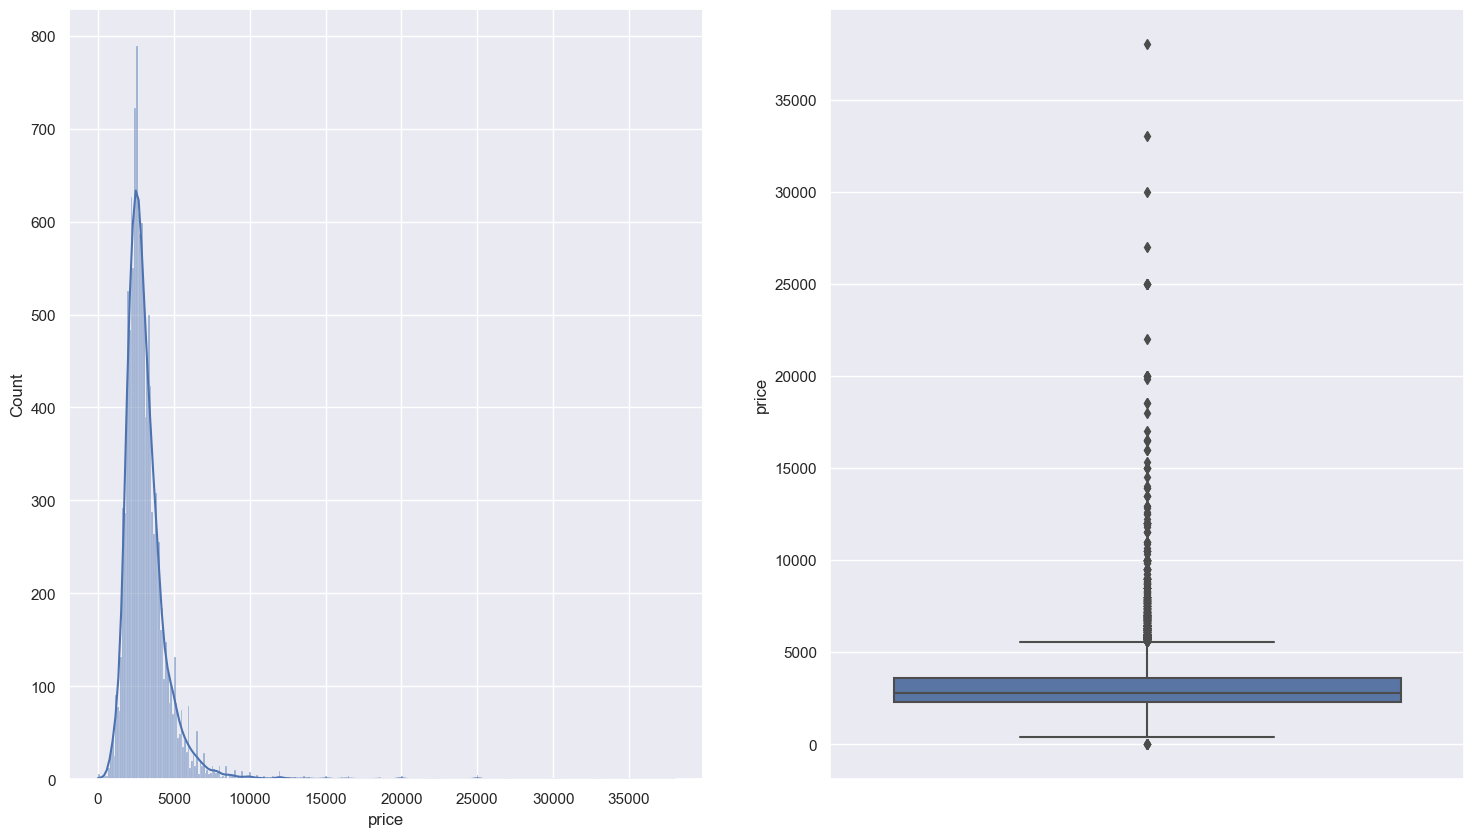

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 10), squeeze=False)
sns.histplot(ax=axes[0,0], data=df_p, x='price', kde=True)
sns.boxplot(ax=axes[0,1], data=df_p, y='price')
# sns.histplot(ax=axes[0,1], data=df, x='price')

In [15]:
def extract_outliers_perntile(df, column, upper=95, lower=5):
    # extract the outliers beyond percentiles
    q_upper, q_lower = np.percentile(df[column], q=[upper,lower])
    
    df_percentile = df[(df[column] < q_lower) | (df[column] > q_upper)]
    print(f'The lower value limit is {q_lower}, and the upper is {q_upper}.\
There are {df_percentile.shape[0]}.')
    return df_percentile

In [16]:
outliers = extract_outliers_perntile(df_p, 'price', 98, 2)
outliers.sort_values(by='price').tail(60)

The lower value limit is 1295.0, and the upper is 6898.999999999996.There are 500.


,url,price,area,location,latitude,longitude,bedrooms,bathrooms,description,property_type,parking,laundry,EV_charging,air_conditioning,furnished,smoking,wheelchair_accessible,cats_allowed,dogs_allowed
5809,https://sfbay.craigslist.org/pen/apa/d/los-alt...,10995,3865ft,Los Altos Hills,37.353170,-122.127843,5,4.5,"['QR Code Link to This Post', 'Gorgeous Los Al...",house,attached garage,w/d in unit,0,0,0,0,0,1,1
5397,https://sfbay.craigslist.org/sfc/apa/d/san-fra...,11000,2466ft,alamo square / nopa,37.779141,-122.435275,4,2.5,"['QR Code Link to This Post', ""Enjoy city life...",flat,attached garage,w/d in unit,0,0,0,0,0,1,1
5357,https://sfbay.craigslist.org/sfc/apa/d/san-fra...,11000,/ 4b,richmond / seacliff,37.778600,-122.489200,4,2.5,"['QR Code Link to This Post', 'San Francisco -...",house,attached garage,w/d in unit,0,0,0,1,0,0,0
1960,https://sfbay.craigslist.org/sfc/apa/d/san-fra...,11500,/ 3b,pacific heights,37.792529,-122.431193,3,2,"['QR Code Link to This Post', 'Mazal55Properti...",condo,attached garage,w/d in unit,0,0,0,0,0,0,0
8518,https://sfbay.craigslist.org/sfc/apa/d/san-fra...,11500,3100ft,west portal / forest hill,37.725726,-122.458199,5,3,"['QR Code Link to This Post', 'ELEGANTLY REFUR...",house,attached garage,w/d in unit,0,0,0,0,0,1,1
10024,https://sfbay.craigslist.org/sfc/apa/d/san-fra...,11500,/ 3b,pacific heights,37.792529,-122.431193,3,2,"['QR Code Link to This Post', 'Mazal55Properti...",condo,attached garage,w/d in unit,0,0,0,0,0,0,0
1831,https://sfbay.craigslist.org/eby/apa/d/pittsbu...,11795,- 871ft,pittsburg / antioch,38.022052,-121.904173,2,1,"['QR Code Link to This Post', 'BELMONT APARTME...",apartment,carport,laundry on site,0,1,0,0,0,0,0
8370,https://sfbay.craigslist.org/eby/apa/d/berkele...,11900,2850ft,berkeley,37.859257,-122.262125,7,2,"['QR Code Link to This Post', '2311 Stuart Str...",house,off-street parking,w/d in unit,0,0,0,0,0,1,1
11277,https://sfbay.craigslist.org/eby/apa/d/alamo-g...,11950,5000ft,Alamo,37.845975,-121.993310,5,4,"['QR Code Link to This Post', 'Darcy Channell,...",house,attached garage,w/d in unit,0,1,0,0,0,1,1
8238,https://sfbay.craigslist.org/nby/apa/d/santa-r...,12000,3300ft,santa rosa,38.464927,-122.687352,4,2.5,"['QR Code Link to This Post', 'Family Furnishe...",house,attached garage,w/d in unit,0,0,1,1,0,0,1


In [17]:
df_p = df_p.drop(outliers.index)
print(f'{len(outliers)} outliers were droped from the "price" feature')

500 outliers were droped from the "price" feature


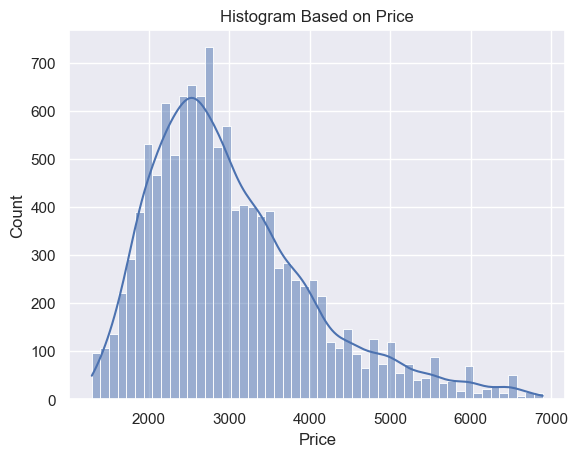

In [18]:
sns.histplot(data=df_p, x='price', kde=True)
plt.title('Histogram Based on Price')
plt.xlabel('Price')
plt.ticklabel_format(style='plain', axis='x') # supresses scientific notation

#### Dealing with the "bathroom" column

In [19]:
def linear_regression_plot(df_f, x, y, up_intercept=0, low_intercept=0,
                           up_slope=0, low_slope=0):
    """
    This function returns the outliers of the linear correlation of two dataframe features 
    x and y. It also draws offset lower and upper lines to visually represent the outliers, 
    which are located outside these lines. 
    
    low_intercept, up_intercept: (integer, integer)
        The offset of the intercept.
        
    low_slope, up_slope: (float, float)
        The offset of the slope.
    """
    
    from scipy.stats import linregress
    reg = linregress(df_f[x], df_f[y])
    print(f'The intercept is {reg.intercept}, and the slope is {reg.slope}')
    
    up_slope_offset = (reg.slope + up_slope)
    up_intercept_offset = reg.intercept + up_intercept
    low_slope_offset = (reg.slope - low_slope)
    low_intercept_offset = reg.intercept - low_intercept
    
    plt.axline((0, up_intercept_offset), slope=up_slope_offset, c='r')
    plt.axline((0, low_intercept_offset), slope=low_slope_offset, c='r')
    
    sns.regplot(df_f,x=x, y=y)
    plt.xlim(0 ,df_f[x].max() + np.percentile(df_f[x], 5))
    plt.ylim(0 ,df_f[y].max() + np.percentile(df_f[y], 5));
    
    outliers = []
    for i in (df_f.index):
        if ((up_slope_offset * df_f.loc[i,x] + up_intercept_offset) <
            (df_f.loc[i,y])):
            outliers.append(i)
        elif ((low_slope_offset * df_f.loc[i,x] + low_intercept_offset) >
            (df_f.loc[i,y])):
            outliers.append(i)
        
    print(f'There are {len(outliers)} outliers.')    
    return outliers

In [20]:
df = df_p.copy()
df_bth = df.copy()

In [21]:
print(f'The unique values in the "bathroom" feature are: \n\n{df_bth.bathrooms.value_counts()}')

The unique values in the "bathroom" feature are: 

1         8091
2         2958
1.5        476
2.5        293
3          147
split       35
3.5         20
shared      18
5            9
4            9
6            2
4.5          2
9+           1
Name: bathrooms, dtype: int64


In [22]:
# Based on my research, if the bathroom is "shared", then the listing is for a room in a shared property.
# "split" or "1.5" means a bathroom and a separate restroom, so we can assign 1.5 for split.
# A value of "9+" is an outlier compare to the other numbers, and we have only 2, so we will drop them.
idx_bath = df_bth[(df_bth['bathrooms'] == 'shared') | (df_bth['bathrooms'] == '9+')].index
df_bth = df_bth.drop(idx_bath)
print(f'Dropping {len(idx_bath)} rows')

df_bth['bathrooms'] = df_bth['bathrooms'].replace('split', 1.5)
df_bth['bathrooms'] = df_bth['bathrooms'].astype(float)

Dropping 19 rows


The intercept is 1614.5033562723129, and the slope is 1060.1277736688883
There are 21 outliers


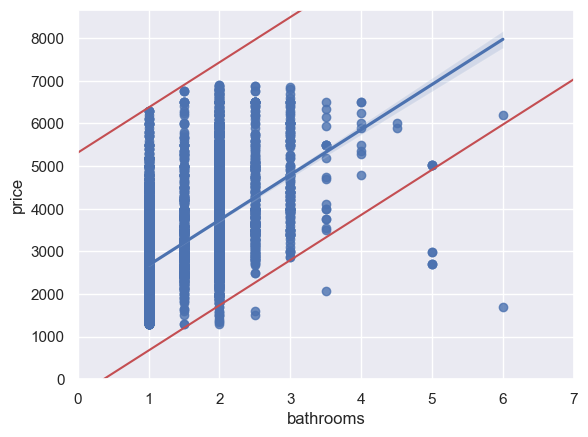

In [23]:
# listings with low price and more than one bathrooms are rooms in a shared property
outliers = linear_regression_plot(df_bth, 'bathrooms', 'price', 3700, 2000, 0, 0)

In [24]:
df_bth = df_bth.drop(outliers) # dropping the above outliers

The intercept is 1564.3668382074416, and the slope is 1101.5449682606175
There are 6 outliers


[1391, 4093, 6362, 8057, 8391, 10786]

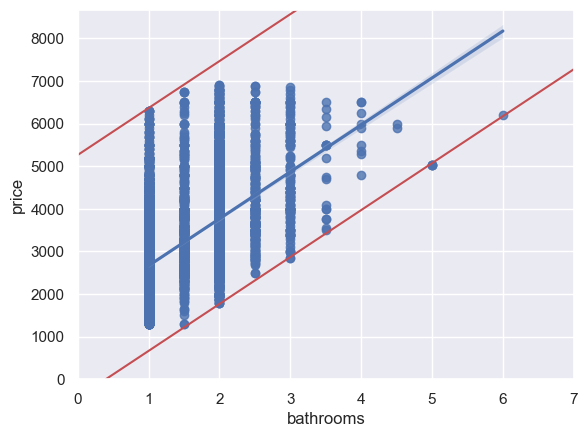

In [25]:
linear_regression_plot(df_bth, 'bathrooms', 'price', 3700, 2000, 0, 0)

#### Dealing with bedrooms

In [26]:
df = df_bth.copy()
df_br = df.copy()

In [27]:
print(f'The unique values in the "bedrooms" feature are: \n\n{df_br.bedrooms.value_counts()}')

The unique values in the "bedrooms" feature are: 

1    4726
2    4497
0    1303
3    1204
4     241
5      47
6       3
Name: bedrooms, dtype: int64


The intercept is 1999.9151082408953, and the slope is 671.2021933169549
There are 17 outliers


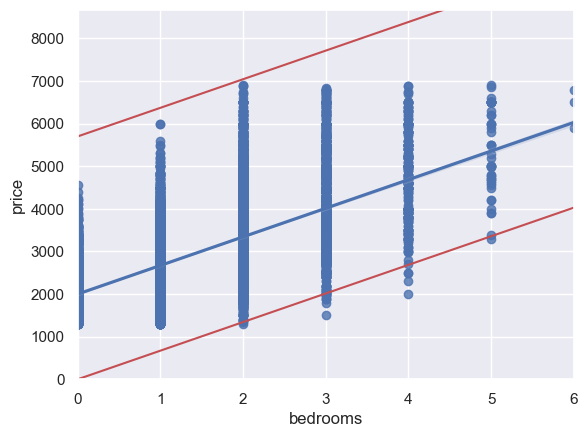

In [28]:
outliers = linear_regression_plot(df_br, 'bedrooms', 'price', 3700, 2000, 0, 0)

In [29]:
df_br = df_br.drop(outliers) # dropping the above outliers

The intercept is 1992.936674054437, and the slope is 677.7232014627447
There are 1 outliers


[5136]

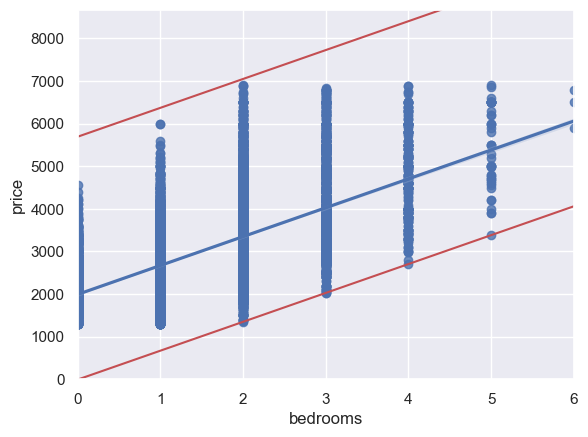

In [30]:
linear_regression_plot(df_br, 'bedrooms', 'price', 3700, 2000, 0, 0)

#### Dealing with location

In [31]:
df = df_br.copy()
df_loc = df.copy()

In [32]:
geolocator = Nominatim(user_agent="geoapiExercises")

In [33]:
# Getting the city, neighborhood, zip code and state based on GPS location.
# A good internet connection is recommended
# This step might take a few hours
unconverted_location = []
for i in (df_loc.index):
    try:
        raw = geolocator.reverse(str(df_loc.loc[i,'latitude'])+","+str(df_loc.loc[i,'longitude'])).raw
        print(i)
        if 'town' in raw['address'].keys():
            df_loc.loc[i, 'city'] = raw['address']['town']
            print(raw['address']['town'])
        elif 'city' in raw['address'].keys():
            df_loc.loc[i, 'city'] = raw['address']['city']
            print(raw['address']['city'])

        if 'neighbourhood' in raw['address'].keys():
            df_loc.loc[i, 'neighbourhood'] = raw['address']['neighbourhood']
            print(raw['address']['neighbourhood'])

        if 'postcode' in raw['address'].keys():
            df_loc.loc[i, 'zip'] = raw['address']['postcode']
            print(raw['address']['postcode'])

        if 'state' in raw['address'].keys():
            df_loc.loc[i, 'state'] = raw['address']['state']
            print(raw['address']['state'])
    
        print('\n')
        time.sleep(1)
    
    except:
        unconverted_location.append(i)
        print(f'Index {i} did not get converted')
print(f'The location of {len(unconverted_location)} listings did not get converted')
if len(unconverted_location) > df_loc.shape[0] * 0.005:
    print('It is advised to run this cell again')

0 out of 12004
Sunnyvale
94089
California


1 out of 12004
San Jose
Meadowfair
95122
California


2 out of 12004
San Francisco
Chinatown
94164
California


3 out of 12004
Mountain View
94041
California


5 out of 12004
Fremont
94536
California


6 out of 12004
San Jose
95117
California


7 out of 12004
San Francisco
Tenderloin
94102
California


8 out of 12004
Hercules
94547
California


9 out of 12004
Sunnyvale
94087
California


10 out of 12004
San Jose
95122
California


12 out of 12004
Oakland
Lower Bottoms
94607
California


13 out of 12004
San Francisco
Nob Hill
90214
California


14 out of 12004
Rohnert Park
94928
California


15 out of 12004
Santa Clara
95051
California


16 out of 12004
Livermore
94550
California


17 out of 12004
Petaluma
94954
California


18 out of 12004
Petaluma
94954
California


19 out of 12004
San Francisco
94122
California


20 out of 12004
Santa Rosa
95401
California


21 out of 12004
San Francisco
Pacific Heights
90214
California


22 out of 12004
Na

171 out of 12004
Fremont
94536
California


172 out of 12004
Concord
94520
California


173 out of 12004
Santa Clara
95051
California


174 out of 12004
Livermore
94550
California


175 out of 12004
Pleasant Hill
Ellinwood
94523
California


176 out of 12004
San Francisco
Dogpatch
41907
California


177 out of 12004
Emeryville
94608
California


178 out of 12004
San Francisco
Jordan Park
94118
California


179 out of 12004
Dublin
94568
California


180 out of 12004
San Francisco
Chinatown
94164
California


181 out of 12004
San Francisco
Chinatown
94164
California


182 out of 12004
Sunnyvale
94086
California


183 out of 12004
Santa Clara
95050
California


184 out of 12004
Oakland
94618
California


185 out of 12004
Oakland
Idora Park
94609
California


186 out of 12004
Oakland
94607
California


187 out of 12004
San Mateo
94403
California


188 out of 12004
San Francisco
Rincon Hill
94105
California


189 out of 12004
Berkeley
LeConte
94701
California


190 out of 12004
Hayward
9454

338 out of 12004
Lafayette
94549
California


339 out of 12004
Santa Monica
90401
California


341 out of 12004
San Francisco
94158
California


342 out of 12004
San Francisco
North Beach
94133
California


343 out of 12004
Santa Rosa
95405
California


344 out of 12004
Campbell
95008
California


345 out of 12004
San Jose
95132
California


346 out of 12004
Los Gatos
95032
California


348 out of 12004
Martinez
94553
California


350 out of 12004
Rohnert Park
94928
California


351 out of 12004
Campbell
95008
California


352 out of 12004
Berkeley
Downtown Berkeley
94704
California


353 out of 12004
San Jose
95121
California


354 out of 12004
San Leandro
94578
California


355 out of 12004
Walnut Creek
94596
California


356 out of 12004
San Jose
95136
California


357 out of 12004
San Francisco
94103
California


358 out of 12004
Mountain View
94041
California


359 out of 12004
Berkeley
LeConte
94701
California


360 out of 12004
Oakland
Temescal
94609
California


361 out of 1200

517 out of 12004
San Francisco
Tenderloin
94102
California


518 out of 12004
Pleasanton
94566
California


519 out of 12004
San Francisco
South of Market
94017
California


521 out of 12004
Fremont
Niles Junction
94536
California


523 out of 12004
Oakland
Harrison/Oakland
94610
California


524 out of 12004
95003
California


525 out of 12004
San Mateo
94402
California


526 out of 12004
Pleasanton
94566
California


527 out of 12004
Mountain View
94041
California


528 out of 12004
Mountain View
Castro City
94043
California


529 out of 12004
San Francisco
Noe Valley
94114
California


530 out of 12004
Santa Rosa
95401
California


532 out of 12004
San Jose
Fruitdale
95126
California


533 out of 12004
San Francisco
Nob Hill
94109
California


535 out of 12004
Burlingame
94010
California


536 out of 12004
Oakland
Lakeside
94612
California


537 out of 12004
Mountain View
94041
California


538 out of 12004
Oakland
Jack London Square
94607
California


539 out of 12004
Alameda
94501

685 out of 12004
San Jose
95134
California


686 out of 12004
95003
California


687 out of 12004
Tiburon
94920
California


688 out of 12004
San Jose
95126
California


689 out of 12004
San Jose
95132
California


690 out of 12004
Hayward
25426
California


691 out of 12004
San Francisco
Potrero Terrace
94124
California


692 out of 12004
Dublin
94568
California


693 out of 12004
Union City
94587
California


694 out of 12004
San Francisco
Castro District
94143
California


695 out of 12004
Oakland
Eastlake
94606
California


696 out of 12004
Rohnert Park
94928
California


697 out of 12004
Livermore
94550
California


698 out of 12004
San Francisco
Castro District
94114
California


699 out of 12004
Mountain View
94043
California


700 out of 12004
San Francisco
94017
California


701 out of 12004
San Francisco
Tenderloin
94108
California


702 out of 12004
Santa Clara
95051
California


703 out of 12004
Millbrae
94030
California


704 out of 12004
Menlo Park
94025
California


705 

...

11980 out of 12004
San Francisco
94121
California


11981 out of 12004
San Francisco
94122
California


11982 out of 12004
Oakland
94606
California


11983 out of 12004
Rohnert Park
94928
California


11985 out of 12004
San Francisco
Excelsior
94112
California


11986 out of 12004
San Francisco
Western Addition
94115
California


11987 out of 12004
Millbrae
94030
California


11988 out of 12004
95062
California


11990 out of 12004
Milpitas
95035
California


11991 out of 12004
San Mateo
94403
California


11992 out of 12004
Pleasanton
94588
California


11993 out of 12004
Mountain View
94043
California


11994 out of 12004
San Francisco
Chinatown
94109
California


11995 out of 12004
Millbrae
94030
California


11996 out of 12004
San Francisco
Duboce Triangle
94143
California


11997 out of 12004
Campbell
95008
California


11998 out of 12004
Sunnyvale
94086
California


11999 out of 12004
San Jose
95136
California


12000 out of 12004
Berkeley
South Berkeley
94703
California


12001 

12141 out of 12004
Millbrae
94030
California


12142 out of 12004
Santa Rosa
95401
California


12143 out of 12004
Milpitas
95035
California


12144 out of 12004
San Francisco
Chinatown
94108
California


12145 out of 12004
San Francisco
Union Square
94102
California


12146 out of 12004
Oakland
Harrison/Oakland
94610
California


12148 out of 12004
Oakland
Idora Park
94609
California


12149 out of 12004
San Pablo
94806
California


12150 out of 12004
Santa Cruz
95060
California


12151 out of 12004
El Cerrito
94530
California


12152 out of 12004
Campbell
95008
California


12154 out of 12004
San Francisco
Russian Hill
94109
California


12155 out of 12004
San Francisco
Haight-Ashbury
94117
California


12156 out of 12004
95010
California


12157 out of 12004
Pleasant Hill
Camelback
94523
California


12158 out of 12004
San Mateo
94403
California


12159 out of 12004
San Francisco
Lower Nob Hill
94108
California


12160 out of 12004
Richmond
94707
California


12161 out of 12004
Berk

12302 out of 12004
San Francisco
Duboce Triangle
94143
California


12303 out of 12004
San Francisco
Castro District
94143
California


12304 out of 12004
San Ramon
94526
California


12305 out of 12004
Hayward
94544
California


12306 out of 12004
San Francisco
94158
California


12307 out of 12004
94946
California


12308 out of 12004
Oakland
Cleveland Heights
94606
California


12309 out of 12004
San Jose
95113
California


12310 out of 12004
Brisbane
94005
California


12311 out of 12004
Lodi
95240
California


12312 out of 12004
San Jose
95131
California


12313 out of 12004
San Francisco
Nob Hill
90214
California


12314 out of 12004
Walnut Creek
94597
California


12315 out of 12004
San Francisco
94143
California


12316 out of 12004
San Bruno
94066
California


12317 out of 12004
San Jose
95125
California


12318 out of 12004
Berkeley
Southside
94704
California


12319 out of 12004
Fremont
94536
California


12320 out of 12004
San Francisco
Glen Park
94112
California


12321 ou

12465 out of 12004
San Francisco
Hayes Valley
94102
California


12467 out of 12004
Walnut Creek
94596
California


12468 out of 12004
Santa Cruz
95062
California


12469 out of 12004
Fremont
94538
California


12470 out of 12004
San Jose
Spartan Keyes
95112
California


12471 out of 12004
95062
California


12472 out of 12004
Oakland
Grand Lake
94610
California


12473 out of 12004
Berkeley
South Berkeley
94703
California


12474 out of 12004
Oakland
Eastlake
94606
California


12475 out of 12004
Walnut Creek
94596
California


12476 out of 12004
Oakland
7th Street Historic District
94607
California


12477 out of 12004
San Francisco
Rincon Hill
94105
California


12478 out of 12004
Milpitas
95035
California


12479 out of 12004
San Francisco
Civic Center
94103
California


12480 out of 12004
Redwood City
94061
California


12481 out of 12004
Burlingame
Burlingame Village
94010
California


12482 out of 12004
95976
California


12483 out of 12004
San Rafael
94901
California


12484 ou

12632 out of 12004
San Francisco
Civic Center
94102
California


12633 out of 12004
San Jose
Saint James Square Historic District
95110
California


12634 out of 12004
San Francisco
Chinatown
94108
California


12635 out of 12004
San Bruno
94066
California


12636 out of 12004
Healdsburg
95448
California


12637 out of 12004
Oakland
Old Oakland Historic District
94607
California


12638 out of 12004
Capitola
95010
California


12639 out of 12004
Fairfield
94533
California


12640 out of 12004
Berkeley
Elmwood
94168
California


12641 out of 12004
Millbrae
94030
California


12642 out of 12004
San Rafael
94901
California


12643 out of 12004
94803
California


12644 out of 12004
Burlingame
94010
California


12645 out of 12004
95041
California


12646 out of 12004
Pleasanton
94566
California


12647 out of 12004
Sunnyvale
94086
California


12648 out of 12004
San Jose
95132
California


12649 out of 12004
Berkeley
LeConte
94701
California


12650 out of 12004
San Francisco
Jordan Park
9

In [35]:
#The GPS coordinates of listings without zip code have incorrectly assigned location, so we drop them
df_loc[df_loc['zip'].isna()]
print(f'Dropping {df_loc[df_loc.zip.isna()].shape[0]} listings without a zip code')
df_loc = df_loc.dropna(subset=['zip'])

Dropping 62 listings without a zip code


In [36]:
df_loc['zip'] = df_loc['zip'].astype(int)

In [37]:
df_loc.state.unique()

array(['California', 'Oregon'], dtype=object)

In [38]:
df_loc = df_loc.drop(df_loc[df_loc['state'] != 'California'].index)

In [39]:
df_loc['neighbourhood'] = df_loc['neighbourhood'].fillna('None')

#### Assigning numbers to categorical columns

In [40]:
df = df_loc.copy()
df_c = df.copy()

#### Dealing with the property_type feature

In [41]:
df_c['property_type'].value_counts()

apartment        10035
house              677
condo              440
townhouse          196
flat               175
duplex             163
in-law             119
cottage/cabin       88
loft                34
land                 3
manufactured         3
Name: property_type, dtype: int64

Listings with property type "loft", "manufactured", "land" and "assisted living" are far different from indoor housing, so they will be dropped

In [42]:
property_type_order = {'in-law': 0, 'cottage/cabin': 1, 'apartment': 2, 'duplex': 3,
                      'condo': 4, 'townhouse': 5, 'house': 6, 'flat': 7}

In [43]:
df_c['property_type'] = df_c['property_type'].map(property_type_order)

In [44]:
print(f'{df_c.property_type.isna().sum()} were dropped due to unrelated property type')
df_c = df_c.dropna()

41 were dropped due to unrelated property type


#### Dealing with the parking feature

In [45]:
df_c['parking'].value_counts()

carport               3528
attached garage       2963
street parking        1573
off-street parking    1521
detached garage        994
no parking             923
valet parking           40
Name: parking, dtype: int64

In [46]:
parking_order = {'no parking': 0, 'off-street parking': 1, 'street parking': 2, 
                 'carport': 3, 'detached garage': 4, 'attached garage': 5, 'valet parking':6}

In [47]:
df_c['parking'] = df_c['parking'].map(parking_order)

#### Dealing with the laundry feature

In [48]:
df_c['laundry'].value_counts()

w/d in unit           6140
laundry on site       2517
laundry in bldg       2051
no laundry on site     491
w/d hookups            343
Name: laundry, dtype: int64

In [49]:
laundry_order = {'no laundry on site': 0, 'laundry on site': 1, 'laundry in bldg': 2,
                'w/d hookups': 3, 'w/d in unit': 4}

In [50]:
df_c['laundry'] = df_c['laundry'].map(laundry_order)

#### Dealing with column "area"

In [79]:
df = df_c.copy()
df_a = df.copy()

In [80]:
def clean_area(x):
    # Every value that represents an actual area size ends with "ft" string
    if x.endswith('ft'):
        return x
    else:
        return None

df_a['area'] = df_a['area'].apply(clean_area)
df_a['area'] = df_a['area'].str.extract('(\d+)')

Now, let's take down the outliers in "area"

In [81]:
# splitting the df into two. One with the null values in the "area" column, which we fill later,
# and one with not null values.
df_a_null = df_a[df_a['area'].isna()]
df_a_not_null = df_a[~df_a['area'].isna()]
df_a_not_null['area'] = df_a_not_null['area'].astype(int)

C:\Users\valto\AppData\Local\Temp\ipykernel_26916\1151692445.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_a_not_null['area'] = df_a_not_null['area'].astype(int)


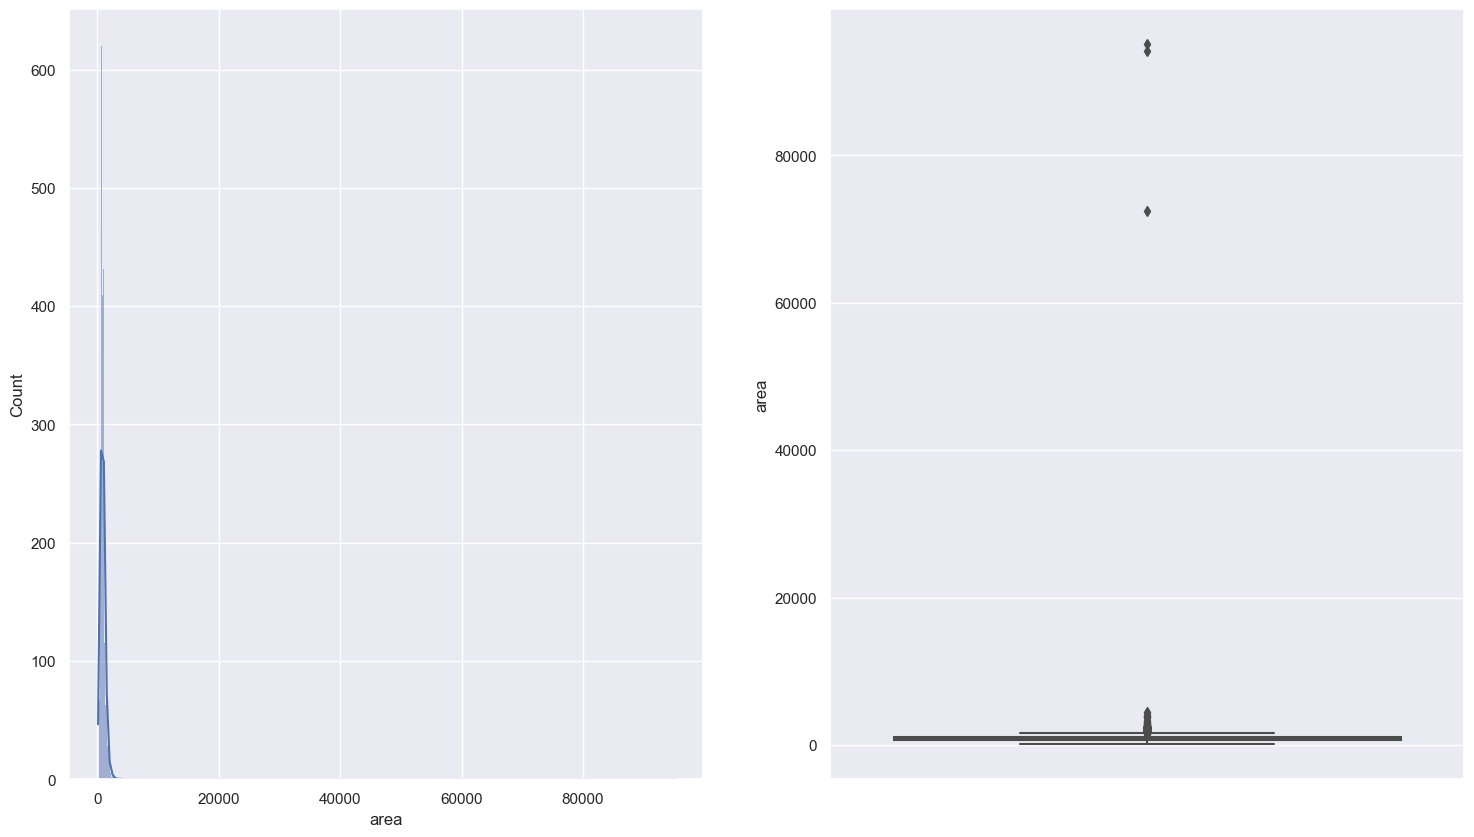

In [82]:
# lets take down the outliers in "area"
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 10), squeeze=False, )
sns.histplot(ax=axes[0,0], data=df_a_not_null, x='area', kde=True, )
sns.boxplot(ax=axes[0,1], data=df_a_not_null, y='area');

In [83]:
outliers = extract_outliers_perntile(df_a_not_null, 'area', 99, 1)

The lower value limit is 312.47, and the upper is 2100.0.There are 174.


In [84]:
df_a_not_null = df_a_not_null.drop(outliers.index)
print(f'{len(outliers)} outliers were droped from the "area" feature')

174 outliers were droped from the "area" feature


The intercept is 1229.3308068525814, and the slope is 2.0848757947515755
There are 207 outliers


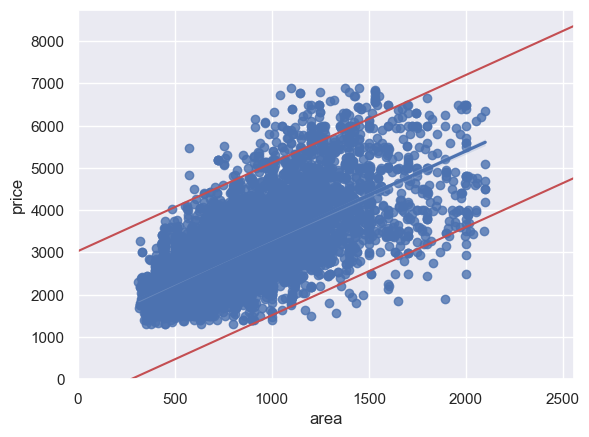

In [85]:
outliers = linear_regression_plot(df_a_not_null, 'area', 'price', 1800, 1800, 0, 0)

In [86]:
df_a_not_null = df_a_not_null.drop(outliers)

The intercept is 1244.3477544541488, and the slope is 2.0259608350187737
There are 19 outliers


[376,
 1244,
 2949,
 3896,
 4496,
 4710,
 5845,
 6035,
 6109,
 6166,
 6278,
 7197,
 7960,
 8666,
 9719,
 9962,
 11131,
 12040,
 12138]

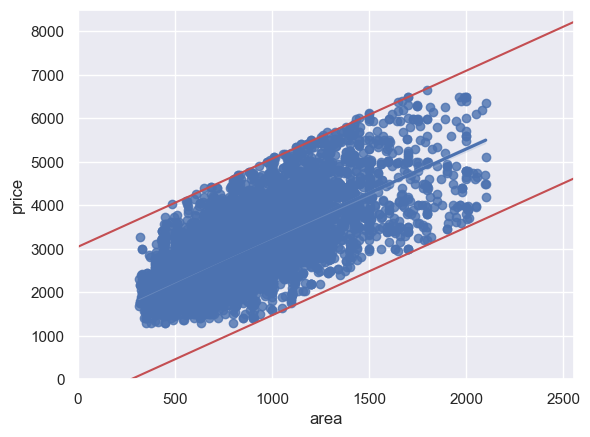

In [87]:
linear_regression_plot(df_a_not_null, 'area', 'price', 1800, 1800, 0, 0)

We will use RandomForestRegressor ML model to fill the missing values.

In [88]:
print(f'We have {df_a.area.isna().sum()} null values in the "area" feature')

We have 2794 null values in the "area" feature


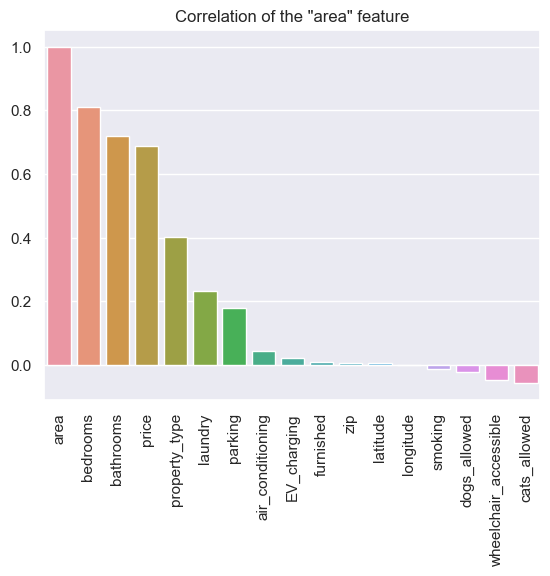

In [89]:
# Lets check the correlation with the "area" feature.
corr = df_a_not_null.corr().area.sort_values(ascending=False)
sns.barplot(x=corr.index, y=corr.values)
plt.xticks(rotation=90);
plt.title('Correlation of the "area" feature');

We will use RandomForestRegressor ML model to fill the missing values.

In [90]:
X = df_a_not_null[['bedrooms', 'bathrooms', 'property_type', 'laundry', 'parking']]
y = df_a_not_null['area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)

In [91]:
rfr = RandomForestRegressor(n_estimators=100, criterion='squared_error', bootstrap=True)
rfr.fit(X_train, y_train)
y_preds = rfr.predict(X_test)

The mean absolute error is 104.7127431874435
The mean squared error is 150.60970508465508


(0.0, 3000.0)

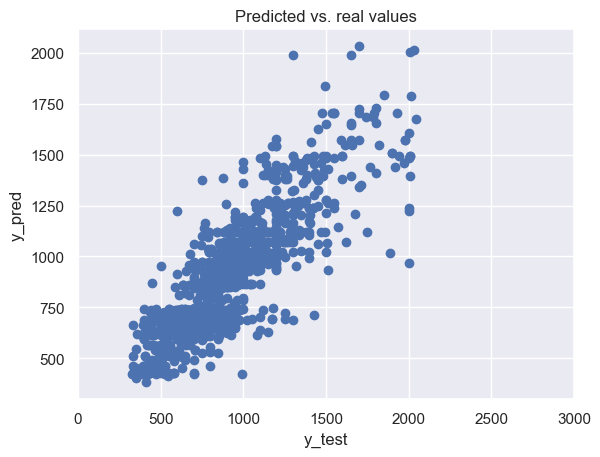

In [92]:
print(f'The mean absolute error is {mean_absolute_error(y_test, y_preds)}')
print(f'The mean squared error is {np.sqrt(mean_squared_error(y_test, y_preds))}')
plt.scatter(y_test, y_preds)
plt.title('Predicted vs. real values')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.xlim(0,3000)

In [93]:
# For the most of the listings the predictions are reasonable, so we will use this model
rfr.fit(X, y)
X_null = df_a_null[['bedrooms', 'bathrooms', 'property_type', 'laundry', 'parking']]
y_null = rfr.predict(X_null)
df_a_null['area'] = y_null
df_a_null['area'] = df_a_null['area'].astype(int)
df_a = pd.concat([df_a_not_null, df_a_null])

C:\Users\valto\AppData\Local\Temp\ipykernel_26916\2231312107.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_a_null['area'] = y_null
C:\Users\valto\AppData\Local\Temp\ipykernel_26916\2231312107.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_a_null['area'] = df_a_null['area'].astype(int)


Text(0.5, 0, 'area sq. ft')

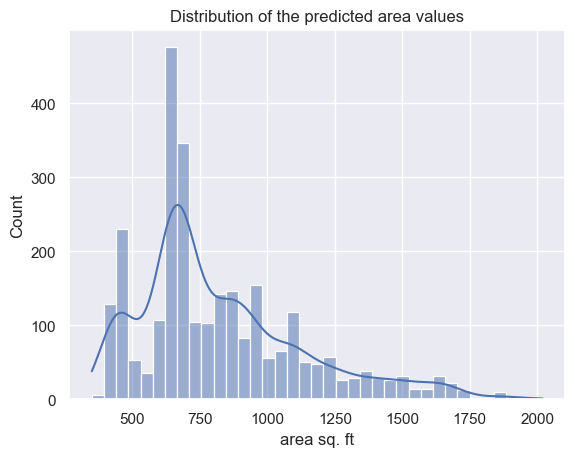

In [94]:
sns.histplot(x=y_null, kde=True)
plt.title('Distribution of the predicted area values')
plt.xlabel('area sq. ft')

Now, let's check for outliers in the "area" feature after filling the null values.

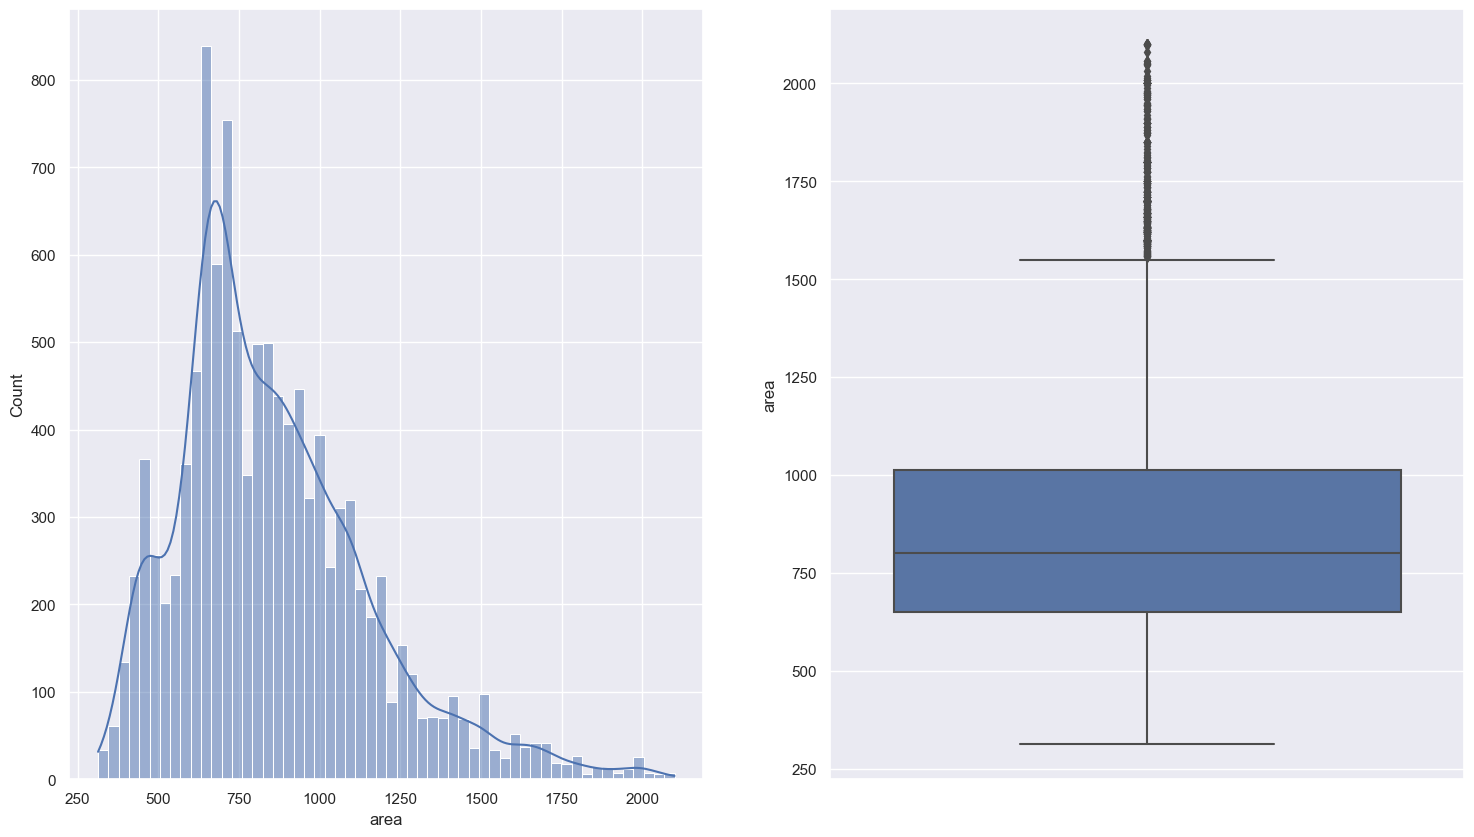

In [95]:
# lets take down the outliers in "area"
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 10), squeeze=False)
sns.histplot(ax=axes[0,0], data=df_a, x='area', kde=True)
sns.boxplot(ax=axes[0,1], data=df_a, y='area');

In [96]:
outliers = extract_outliers_perntile(df_a, 'area', 99, 1)

The lower value limit is 387.0, and the upper is 1800.0.There are 207.


In [97]:
# df_a = df_a.drop(outliers.index)
# print(f'{len(outliers)} outliers were droped from the "area" feature')

The intercept is 1137.0612778561083, and the slope is 2.1669466985110337
There are 133 outliers


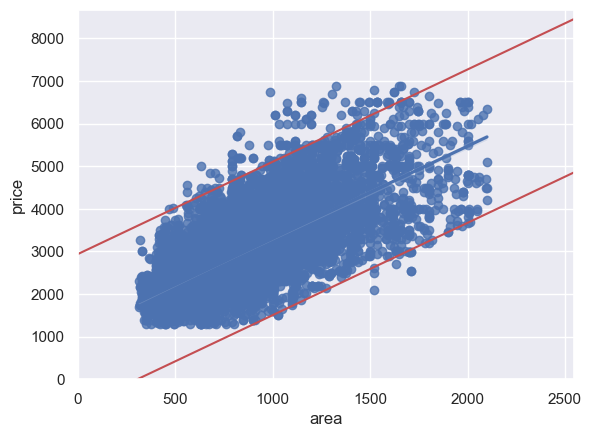

In [98]:
outliers = linear_regression_plot(df_a, 'area', 'price', 1800, 1800, 0, 0)

In [99]:
df_a = df_a.drop(outliers)

#### The preprocessing has been done

In [100]:
df = df_a.copy()
df = df.reset_index(drop=True)

In [101]:
print(f'{df_org_size - df.shape[0]} rows were dropped during the preprocessing.')

1659 rows were dropped during the preprocessing


The number of dropped rows might seem high, but keep in mind this is very mixed up data where no one regulates the integrity of the listings.

In [103]:
df.describe()

,price,area,latitude,longitude,bedrooms,bathrooms,property_type,parking,laundry,EV_charging,air_conditioning,furnished,smoking,wheelchair_accessible,cats_allowed,dogs_allowed,zip
count,11028.00000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000,11028.000000
mean,2963.93045,851.767501,37.703195,-122.214002,1.501995,1.311026,2.354552,2.956112,2.781012,0.188520,0.311299,0.041712,0.353101,0.231048,0.660138,0.608633,94000.181357
std,903.31851,296.866302,0.284910,0.243208,0.871282,0.496307,1.133979,1.569373,1.389376,0.391145,0.463046,0.199939,0.477955,0.421522,0.473684,0.488078,5254.317999
min,1295.00000,313.000000,34.017600,-122.916150,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25426.000000
25%,2295.00000,650.000000,37.485637,-122.415302,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94121.000000
50%,2800.00000,800.000000,37.766622,-122.259021,1.000000,1.000000,2.000000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,94547.000000
75%,3495.00000,1008.250000,37.821901,-122.017700,2.000000,2.000000,2.000000,4.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,94850.000000
max,6650.00000,2100.000000,39.071090,-117.849169,6.000000,5.000000,7.000000,6.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,95688.000000


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11028 entries, 0 to 11027
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   url                    11028 non-null  object 
 1   price                  11028 non-null  int32  
 2   area                   11028 non-null  int32  
 3   location               11028 non-null  object 
 4   latitude               11028 non-null  float64
 5   longitude              11028 non-null  float64
 6   bedrooms               11028 non-null  int64  
 7   bathrooms              11028 non-null  float64
 8   description            11028 non-null  object 
 9   property_type          11028 non-null  float64
 10  parking                11028 non-null  int64  
 11  laundry                11028 non-null  int64  
 12  EV_charging            11028 non-null  int64  
 13  air_conditioning       11028 non-null  int64  
 14  furnished              11028 non-null  int64  
 15  sm

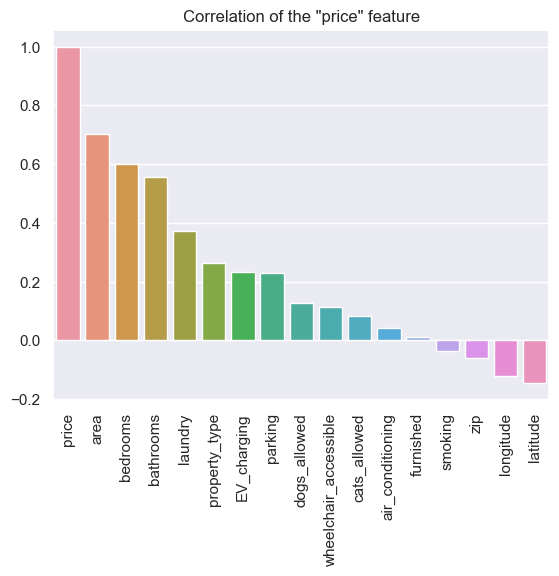

In [105]:
corr = df.corr().price.sort_values(ascending=False)
sns.barplot(x=corr.index, y=corr.values)
plt.xticks(rotation=90);
plt.title('Correlation of the "price" feature');

In [106]:
df = df.drop('description', axis=1)

In [108]:
df.to_csv(f'apt_house_sfbay_df_{dt.now().strftime("%Y-%m-%d")}.csv')